# CNN for Artist Classification

Optimized CNN pipeline using **ResNet-18 transfer learning** with two-phase fine-tuning, art-specific augmentations, and comprehensive evaluation.

In [1]:
import sys
print(sys.executable)


c:\Users\Josh Hall\Documents\GitHub\487finalproj\.venv310\Scripts\python.exe


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models          # ADDED: for pretrained ResNet-18
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import copy                                   # ADDED: for early stopping (save best weights)
from sklearn.metrics import (                 # ADDED: for evaluation metrics
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    try:
        import torch_directml
        device = torch_directml.device()
        print("Using DirectML (AMD GPU)")
    except ImportError:
        device = torch.device("cpu")

print("Using device:", device)

c:\Users\Josh Hall\Documents\GitHub\487finalproj\.venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using DirectML (AMD GPU)
Using device: privateuseone:0


# Artist Classification — Model Overview

This notebook trains a neural network to classify paintings into one of 20 artist categories. The dataset contains roughly 10,000 images split across training (8K), validation (1K), and test (1K) sets, with approximately 400–500 images per artist. With so few examples per class, training a convolutional network from scratch would overfit badly — making transfer learning the natural approach.

The model is built on **ResNet-18 pretrained on ImageNet**. The original 1,000-class output head is replaced with a two-layer head: `Dropout(0.4) → Linear(512 → 20)`. The pretrained backbone already knows how to detect edges, textures, and color gradients — the same low-level visual primitives that define a painting's style — so most of the learning work is already done before training begins.

Training follows a **two-phase fine-tuning strategy**. In Phase 1 (epochs 1–10), the backbone is fully frozen and only the new head trains at LR=1e-3; this teaches the model to map existing ImageNet features to artist classes without disturbing the pretrained weights. In Phase 2 (epochs 11–40), the deeper layers (`layer3` and `layer4`) are unfrozen and fine-tuned at a lower LR=1e-4 to adapt high-level features toward art-specific patterns while preserving the low-level detectors learned from ImageNet. AdamW with cosine annealing, label smoothing (0.1), and early stopping (patience=5) are used throughout. The final model achieves **84.2% top-1 test accuracy** (93.4% top-3, 95.4% top-5).

## Configuration

**Key changes from baseline:**
- **224x224** — standard for pretrained models; captures brushstroke texture and composition detail that 64x64 destroys
- **SAMPLE_FRAC = 1.0** — uses all 8K training images (400/class) instead of 11% (~44/class)
- **40 epochs** with early stopping (patience=5) so we don't overfit
- **Two-phase training** — Phase 1: frozen backbone (10 epochs, LR=1e-3). Phase 2: unfreeze deeper layers (remaining epochs, LR=1e-4)

In [3]:
# --- CHANGED: all values updated from baseline ---
IMG_SIZE = 224            # was 64; 224 is standard for ImageNet-pretrained models
BATCH_SIZE = 32           # was 64; reduced to fit 224x224 images in GPU memory
NUM_EPOCHS = 40           # was 2; early stopping will cut this short if we overfit
LEARNING_RATE = 1e-3      # phase 1 LR (frozen backbone, training FC head only)
FINETUNE_LR = 1e-4        # ADDED: phase 2 LR (lower to avoid destroying pretrained features)
WEIGHT_DECAY = 1e-2       # ADDED: L2 regularization via AdamW
SAMPLE_FRAC = 1.0         # was 0.11; now using all training data
NUM_CLASSES = 20
PATIENCE = 5              # ADDED: early stopping patience (stop after 5 epochs with no improvement)
PHASE1_EPOCHS = 10        # ADDED: number of epochs to train with frozen backbone
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

## Load Splits

train 8K, val 1K, test 1K

In [4]:
# # UNCOMMENT THIS IF YOU'RE HAVING DISK SPACE ISSUES
# from datasets import disable_caching
# disable_caching()  # prevents HF from writing ~4GB Arrow cache to disk

raw = load_dataset("parquet", data_files={
    "train": "train.parquet",
    "val":   "val.parquet",
    "test":  "test.parquet",
}, keep_in_memory=True) # there may be a better way to do this, but this writes to memory


train_hf = raw["train"]
val_hf   = raw["val"]
test_hf  = raw["test"]

if SAMPLE_FRAC < 1.0:
    n_train = max(1, int(len(train_hf) * SAMPLE_FRAC))
    n_val   = max(1, int(len(val_hf)   * SAMPLE_FRAC))
    train_hf = train_hf.shuffle(seed=SEED).select(range(n_train))
    val_hf   = val_hf.shuffle(seed=SEED).select(range(n_val))

print(f"Train: {len(train_hf)}  |  Val: {len(val_hf)}  |  Test: {len(test_hf)}")

# Build artist → label mapping
artist_names = sorted(set(train_hf["artist"]))
artist2idx = {name: i for i, name in enumerate(artist_names)}
idx2artist = {i: name for name, i in artist2idx.items()}
print(f"Classes ({len(artist_names)}): {artist_names[:5]} ...")

Train: 8000  |  Val: 1000  |  Test: 1000
Classes (20): [0, 1, 2, 3, 4] ...


## Dataset & DataLoaders

In [5]:
# --- CHANGED: art-specific augmentation pipeline ---
# Each augmentation is chosen to help the model generalize on painting data:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # resize to 256x256 first
    transforms.RandomCrop(IMG_SIZE),          # ADDED: random 224x224 crop — forces learning from partial views
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(                   # ADDED: robustness to photo lighting conditions
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.05,             # hue kept low — color palette is key to artist ID
    ),
    transforms.RandomAffine(                  # ADDED: handles slight camera angles on paintings
        degrees=10, translate=(0.05, 0.05),
        scale=(0.9, 1.1),
    ),
    transforms.RandomGrayscale(p=0.05),       # ADDED: forces model to learn texture, not just color
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.15)),  # ADDED: like Cutout — forces using multiple regions
])
# NOTE: we do NOT add RandomVerticalFlip (paintings have canonical up/down orientation)
# NOTE: we do NOT add GaussianBlur (would destroy brushstroke texture, a key artist signal)

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # no augmentation for eval — just resize
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class ArtDataset(Dataset):
    """Wraps a HuggingFace dataset split into a PyTorch Dataset."""

    def __init__(self, hf_dataset, artist2idx, transform=None):
        self.hf = hf_dataset
        self.artist2idx = artist2idx
        self.transform = transform

    def __len__(self):
        return len(self.hf)

    def __getitem__(self, idx):
        item = self.hf[idx]
        img = item["image"].convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.artist2idx[item["artist"]]
        return img, label


train_ds = ArtDataset(train_hf, artist2idx, train_transform)
val_ds   = ArtDataset(val_hf,   artist2idx, eval_transform)
test_ds  = ArtDataset(test_hf,  artist2idx, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches per epoch — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Batches per epoch — train: 250, val: 32, test: 32


## Model Architecture — ResNet-18 Transfer Learning

**Why transfer learning instead of a deeper custom CNN?**
With only 400 images/class, a from-scratch CNN will either underfit (too shallow) or overfit (too deep). ResNet-18 pretrained on ImageNet provides powerful low-level feature extractors (edges, textures, color gradients) that transfer directly to art classification — paintings are built from the same visual primitives.

**Why ResNet-18 specifically?**
- Uses only standard ops (Conv2d, BN, ReLU, MaxPool, AdaptiveAvgPool) — all DirectML-compatible
- Skip connections enable deeper feature extraction without vanishing gradients
- 11.7M total params, but most are frozen — only ~2.4M trainable in phase 2

**Two-phase strategy:**
1. **Phase 1:** Freeze all pretrained layers, train only the new FC head
2. **Phase 2:** Unfreeze `layer3` + `layer4`, fine-tune with lower LR

In [6]:
# --- CHANGED: replaced SimpleCNN with pretrained ResNet-18 ---
# Load ResNet-18 with ImageNet weights (pretrained on 1.2M images)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all pretrained layers — Phase 1 trains only the FC head
for param in model.parameters():
    param.requires_grad = False

# Replace the final FC layer (was: 512 -> 1000 ImageNet classes)
# New head: Dropout(0.4) for regularization -> Linear(512 -> 20 artists)
model.fc = nn.Sequential(
    nn.Dropout(0.4),                          # ADDED: higher dropout than baseline (was 0.3)
    nn.Linear(model.fc.in_features, NUM_CLASSES),  # 512 -> 20
)

model = model.to(device)

# Count trainable vs total params
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable (Phase 1):  {trainable_params:,}")
print(f"Frozen:               {total_params - trainable_params:,}")

Total parameters:     11,186,772
Trainable (Phase 1):  10,260
Frozen:               11,176,512


## Training Loop — Two-Phase Fine-Tuning

**Phase 1** (epochs 1–10): Backbone frozen, only FC head trains at LR=1e-3. Learns mapping from ImageNet features → artist classes.

**Phase 2** (epochs 11–40): Unfreeze `layer3` + `layer4`, drop LR to 1e-4. Fine-tunes higher-level features to become art-specific while preserving low-level edge/texture detectors.

**Training improvements over baseline:**
- **AdamW** — properly decouples weight decay from adaptive LR (unlike Adam + L2)
- **Cosine LR schedule** — smoothly anneals LR from high→low for precise convergence
- **Early stopping** (patience=5) — saves best model, stops when val loss stops improving
- **Label smoothing** (0.1) — prevents overconfidence; useful when artist styles overlap
- **Gradient clipping** (max_norm=1.0) — prevents exploding gradients during fine-tuning

In [7]:
# --- CHANGED: label smoothing prevents overconfidence on ambiguous artist styles ---
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # was: no label smoothing

# --- CHANGED: AdamW decouples weight decay properly (unlike Adam + L2) ---
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),  # only trainable params
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,       # ADDED: L2 regularization
    foreach=False,                   # ADDED: avoids lerp ops unsupported on DirectML
)

# --- ADDED: cosine LR schedule — high LR early, smoothly decays for fine convergence ---
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS, eta_min=1e-6)

# --- ADDED: early stopping tracking ---
best_val_loss = float('inf')
best_val_acc = 0.0
patience_counter = 0
best_weights = None

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}

for epoch in range(1, NUM_EPOCHS + 1):

    # --- ADDED: Phase 2 transition — unfreeze deeper layers with lower LR ---
    if epoch == PHASE1_EPOCHS + 1:
        print("\n>>> Phase 2: Unfreezing layer3 + layer4 for fine-tuning <<<\n")
        for param in model.layer3.parameters():
            param.requires_grad = True
        for param in model.layer4.parameters():
            param.requires_grad = True

        # New optimizer with lower LR for fine-tuning (avoids destroying pretrained features)
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=FINETUNE_LR,
            weight_decay=WEIGHT_DECAY,
            foreach=False,           # ADDED: avoids lerp ops unsupported on DirectML
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - PHASE1_EPOCHS, eta_min=1e-6
        )
        patience_counter = 0  # reset patience for phase 2

        trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Trainable params (Phase 2): {trainable_now:,}\n")

    # --- Training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        # --- ADDED: gradient clipping — prevents exploding gradients during fine-tuning ---
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # --- Validation ---
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc  = correct / total

    current_lr = optimizer.param_groups[0]['lr']
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    # --- ADDED: early stopping — saves best model, stops if no improvement ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0
        best_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    phase = "P1" if epoch <= PHASE1_EPOCHS else "P2"
    print(f"[{phase}] Epoch {epoch}/{NUM_EPOCHS}  "
          f"train_loss={train_loss:.4f}  train_acc={train_acc:.3f}  "
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.3f}  "
          f"lr={current_lr:.2e}  patience={patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} — best val_acc={best_val_acc:.3f}")
        break

    scheduler.step()

# Restore best weights
if best_weights is not None:
    model.load_state_dict(best_weights)
    print(f"\nRestored best model (val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.3f})")

c:\Users\Josh Hall\Documents\GitHub\487finalproj\.venv310\lib\site-packages\torch\optim\adamw.py:380: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  exp_avg.lerp_(grad, 1 - beta1)


[P1] Epoch 1/40  train_loss=2.5771  train_acc=0.257  val_loss=2.0377  val_acc=0.484  lr=1.00e-03  patience=0/5
[P1] Epoch 2/40  train_loss=2.1910  train_acc=0.401  val_loss=1.9250  val_acc=0.493  lr=9.76e-04  patience=0/5
[P1] Epoch 3/40  train_loss=2.0941  train_acc=0.443  val_loss=1.7918  val_acc=0.556  lr=9.05e-04  patience=0/5
[P1] Epoch 4/40  train_loss=2.0533  train_acc=0.456  val_loss=1.7910  val_acc=0.568  lr=7.94e-04  patience=0/5
[P1] Epoch 5/40  train_loss=2.0377  train_acc=0.464  val_loss=1.7417  val_acc=0.578  lr=6.55e-04  patience=0/5
[P1] Epoch 6/40  train_loss=2.0067  train_acc=0.477  val_loss=1.7454  val_acc=0.579  lr=5.01e-04  patience=1/5
[P1] Epoch 7/40  train_loss=1.9956  train_acc=0.476  val_loss=1.7309  val_acc=0.584  lr=3.46e-04  patience=0/5
[P1] Epoch 8/40  train_loss=1.9861  train_acc=0.486  val_loss=1.7105  val_acc=0.597  lr=2.07e-04  patience=0/5
[P1] Epoch 9/40  train_loss=1.9811  train_acc=0.481  val_loss=1.7111  val_acc=0.590  lr=9.64e-05  patience=1/5
[

## Training Curves

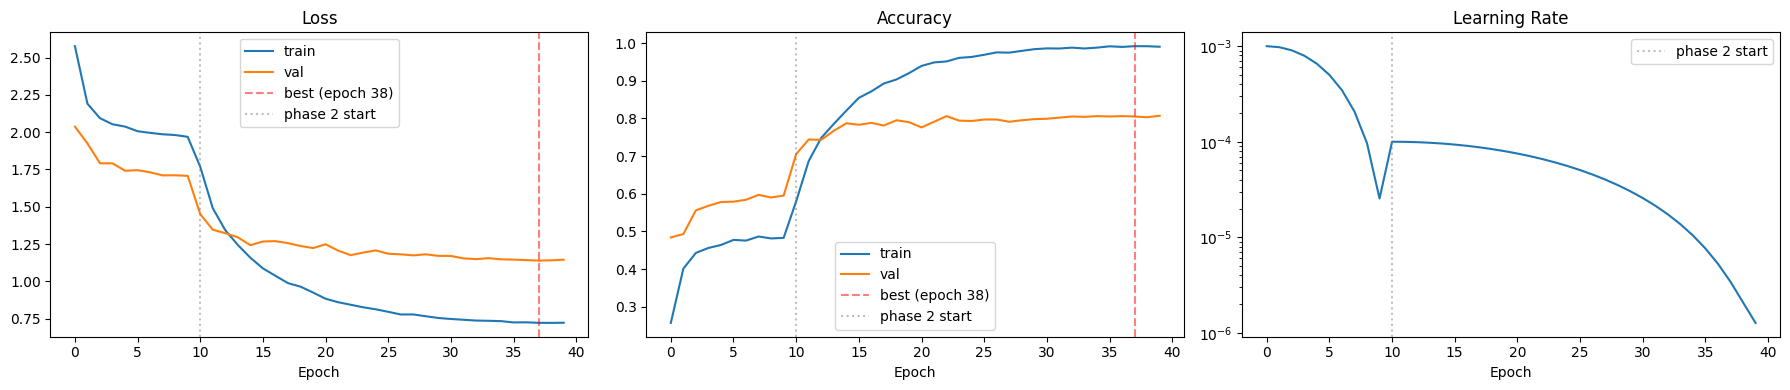

In [8]:
# --- CHANGED: added LR plot and best-epoch marker ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
best_epoch = np.argmin(history["val_loss"])
axes[0].axvline(x=best_epoch, color='r', linestyle='--', alpha=0.5, label=f"best (epoch {best_epoch+1})")
if PHASE1_EPOCHS < len(history["val_loss"]):
    axes[0].axvline(x=PHASE1_EPOCHS, color='gray', linestyle=':', alpha=0.5, label="phase 2 start")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

# Accuracy
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].axvline(x=best_epoch, color='r', linestyle='--', alpha=0.5, label=f"best (epoch {best_epoch+1})")
if PHASE1_EPOCHS < len(history["val_acc"]):
    axes[1].axvline(x=PHASE1_EPOCHS, color='gray', linestyle=':', alpha=0.5, label="phase 2 start")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

# ADDED: Learning rate schedule plot
axes[2].plot(history["lr"])
if PHASE1_EPOCHS < len(history["lr"]):
    axes[2].axvline(x=PHASE1_EPOCHS, color='gray', linestyle=':', alpha=0.5, label="phase 2 start")
axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch"); axes[2].set_yscale("log"); axes[2].legend()

plt.tight_layout()
plt.show()

## Test Evaluation

**Added metrics beyond baseline per-class accuracy:**
- **Confusion matrix** — shows which artists get confused with each other (reveals if errors cluster within art movements)
- **Classification report** — precision, recall, F1 per class (accuracy alone hides class-level problems)
- **Top-3 / Top-5 accuracy** — with 20 classes and stylistic overlap, top-k shows the model "gets close" even when top-1 is wrong

Test Accuracy (Top-1): 0.8420
Test Accuracy (Top-3): 0.9340
Test Accuracy (Top-5): 0.9540

Per-class accuracy:
  artist 0      acc=0.300  (n=50)
  artist 1      acc=0.800  (n=50)
  artist 2      acc=0.880  (n=50)
  artist 3      acc=0.900  (n=50)
  artist 4      acc=0.780  (n=50)
  artist 5      acc=0.880  (n=50)
  artist 6      acc=0.980  (n=50)
  artist 7      acc=1.000  (n=50)
  artist 9      acc=0.980  (n=50)
  artist 11     acc=0.800  (n=50)
  artist 12     acc=0.940  (n=50)
  artist 13     acc=0.840  (n=50)
  artist 14     acc=0.820  (n=50)
  artist 15     acc=0.740  (n=50)
  artist 16     acc=0.800  (n=50)
  artist 17     acc=0.880  (n=50)
  artist 18     acc=0.820  (n=50)
  artist 20     acc=0.920  (n=50)
  artist 22     acc=0.800  (n=50)
  artist 25     acc=0.980  (n=50)

--- F1 Score Summary ---
  Macro    F1: 0.836
  Weighted F1: 0.836

Per-class F1:
  artist 0      precision=0.536  recall=0.300  f1=0.385
  artist 1      precision=0.784  recall=0.800  f1=0.792
  artist 2    

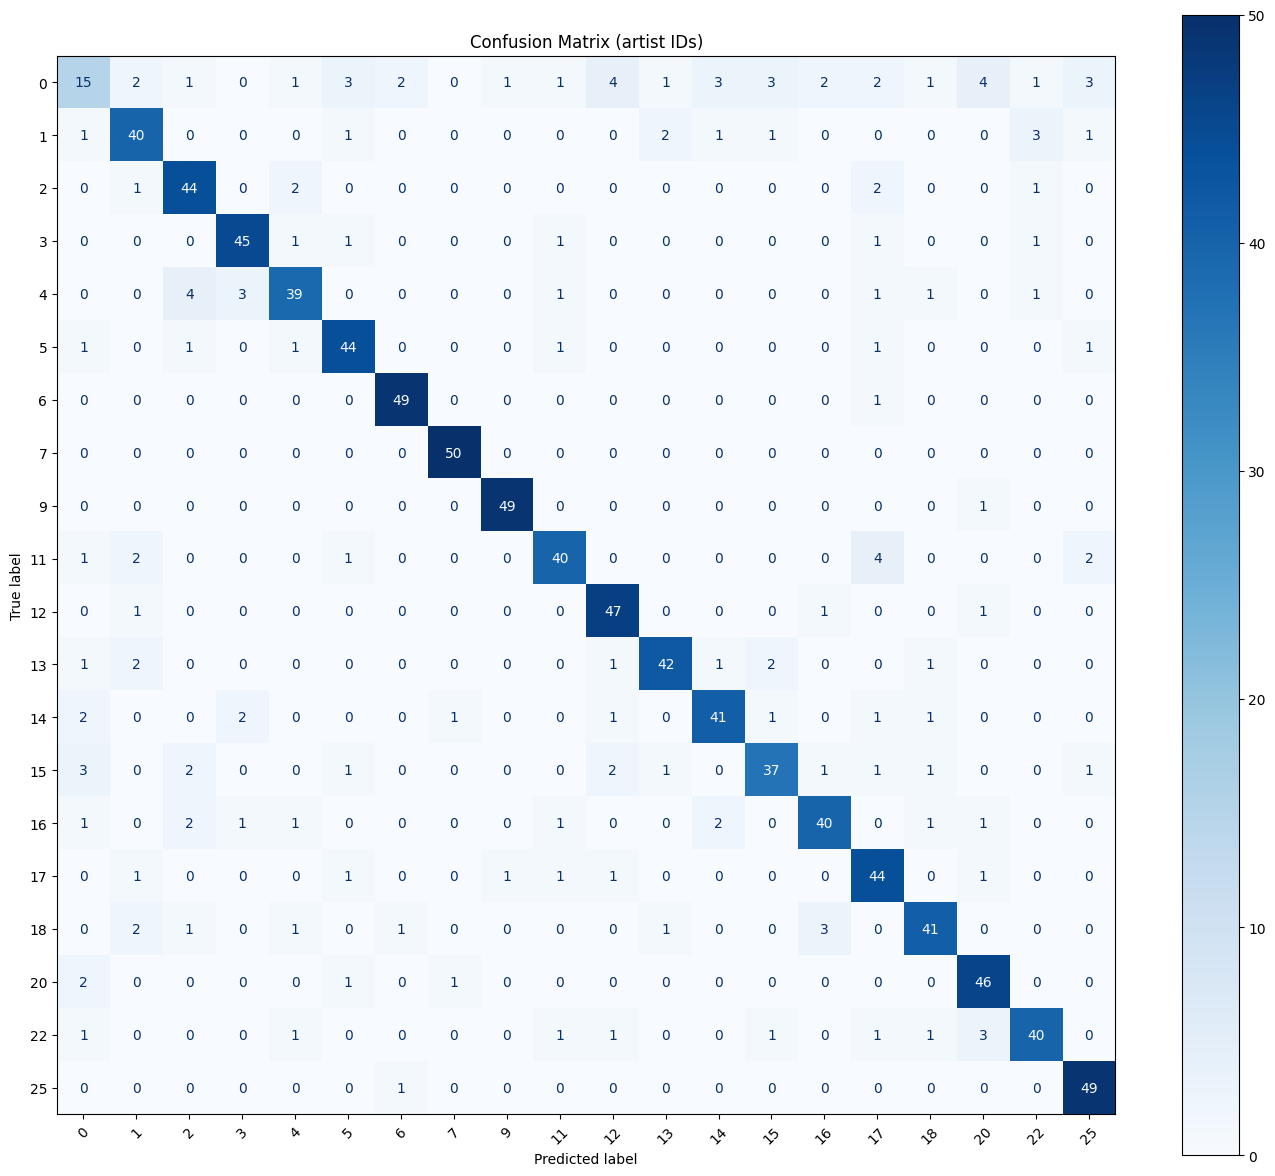

In [12]:
model.eval()
all_preds, all_labels, all_logits = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs).cpu()
        all_logits.append(logits)
        all_preds.append(logits.argmax(1))
        all_labels.append(labels)

all_logits = torch.cat(all_logits)
all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# --- Top-1 accuracy ---
test_acc = (all_preds == all_labels).float().mean().item()
print(f"Test Accuracy (Top-1): {test_acc:.4f}")

# --- Top-3 and Top-5 accuracy ---
for k in [3, 5]:
    _, topk_preds = all_logits.topk(k, dim=1)
    topk_correct = topk_preds.eq(all_labels.unsqueeze(1)).any(dim=1).sum().item()
    topk_acc = topk_correct / len(all_labels)
    print(f"Test Accuracy (Top-{k}): {topk_acc:.4f}")

# --- Per-class accuracy ---
print("\nPer-class accuracy:")
for cls_idx in range(NUM_CLASSES):
    mask = all_labels == cls_idx
    if mask.sum() == 0:
        continue
    cls_acc = (all_preds[mask] == all_labels[mask]).float().mean().item()
    print(f"  artist {str(idx2artist[cls_idx]):<5}  acc={cls_acc:.3f}  (n={mask.sum().item()})")

# --- Classification report ---
target_names = [f"artist {idx2artist[i]}" for i in range(NUM_CLASSES)]
report_dict = classification_report(
    all_labels.numpy(), all_preds.numpy(),
    target_names=target_names,
    digits=3,
    output_dict=True,
)

# Print F1 summary clearly
print("\n--- F1 Score Summary ---")
print(f"  Macro    F1: {report_dict['macro avg']['f1-score']:.3f}")
print(f"  Weighted F1: {report_dict['weighted avg']['f1-score']:.3f}")
print(f"\nPer-class F1:")
for name in target_names:
    f1  = report_dict[name]['f1-score']
    prec = report_dict[name]['precision']
    rec  = report_dict[name]['recall']
    print(f"  {name:<12}  precision={prec:.3f}  recall={rec:.3f}  f1={f1:.3f}")

# Full report
print("\nFull Classification Report:")
print(classification_report(
    all_labels.numpy(), all_preds.numpy(),
    target_names=target_names,
    digits=3,
))

# --- Confusion matrix ---
fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())
disp = ConfusionMatrixDisplay(cm, display_labels=[str(idx2artist[i]) for i in range(NUM_CLASSES)])
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='d')
ax.set_title("Confusion Matrix (artist IDs)")
plt.tight_layout()
plt.show()